In [ ]:
from pilot.models        import LogDeepONet, build_deeponet
from pilot.data          import ODEIterableDataset, DirichletSampler
from pilot.physics       import Robertson
from pilot.training      import Trainer, build_dataloaders

import numpy as np
import matplotlib.pyplot as plt 
from matplotlib.colors import LinearSegmentedColormap

import torch
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

colors = ["red", "darkviolet", "deepskyblue"]
cmap   = LinearSegmentedColormap.from_list("high_contrast", colors)

In [2]:
# Initialize Roberston Model
k1 = 4e-2
k2 = 3e7
k3 = 1e4
system = Robertson([k1, k2, k3])

# Initialize Sampler Object 
sampler = DirichletSampler(alpha=[1, 1, 1])

In [3]:
dataset_size = 1001
batch_size   = 1
num_workers  = 2
t_final      = 1e4
t_span       = (0, t_final)

rob_dataset = ODEIterableDataset(size          = dataset_size,
                                 system_class  = system,
                                 sampler       = sampler,
                                 t_span        = t_span,
                                 full_solution = True,
                                 method        = "BDF")

rob_loader  = DataLoader(dataset     = rob_dataset,
                         batch_size  = batch_size,
                         num_workers = num_workers)


In [4]:
# Set Up DeepONet configuration 

DEEPONET_CONFIG = {
    
    "hidden_size" : 64,
    "depth"       : 4,
    "latent_size" : 120,
    "input_size_b": 3,
    "input_size_t": 1,
    "output_size" : 3,
    "activation"  : "tanh",
    "t_span"      : t_span

}


# 1. Initialize DeepONet network 

deeponet = build_deeponet(DEEPONET_CONFIG)

# 2. Load the saved weights into the model

state_dict = torch.load("../../weights/bad_robertson.pth", map_location=device)
deeponet.load_state_dict(state_dict)
deeponet = deeponet.to(device)

# 3. Set to eval mode
deeponet.eval()
_ = 0

In [ ]:
from pilot.benchmark import trajectory 

t, sol, pred = trajectory(deeponet, rob_loader, device)

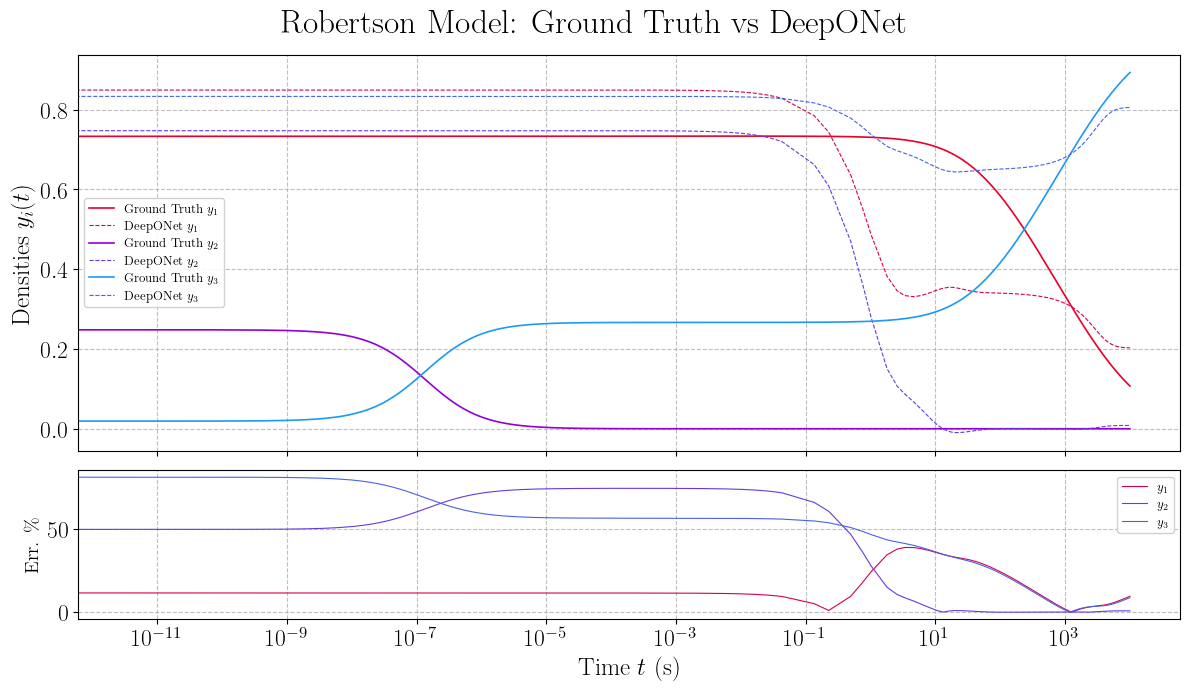

In [15]:

fig, axs = plt.subplots(2, 1, figsize=(12, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [4, 1.5]})

ax_main = axs[0]
ax_res  = axs[1]

gt_colors   = [cmap(0.1), cmap(0.5), cmap(0.9)]
pred_colors = [cmap(0.2), cmap(0.65), cmap(0.75)]


# --- Main plot ---
for i, (cgt, cpred) in enumerate(zip(gt_colors, pred_colors)):
    ax_main.plot(t, sol[i],     lw=1.2, color=cgt,   label=rf"Ground Truth $y_{i+1}$")
    ax_main.plot(t, pred[:, i], lw=0.8, color=cpred, label=rf"DeepONet $y_{i+1}$", linestyle="--")

ax_main.set_xscale("log")
ax_main.set_ylabel(rf"Densities $y_i(t)$", fontsize=18)
ax_main.legend(fontsize=9, framealpha=0.9)
ax_main.grid(linestyle="--", alpha=0.8)
ax_main.tick_params(axis='both', labelsize=17) 


# --- Residuals ---
for i, color in enumerate([cmap(0.2), cmap(0.65), cmap(0.75)]):
    residual  = np.abs(sol[i] - pred[:, i]) * 100
    ax_res.plot(t, residual, lw=0.8, color=color, label=rf"$y_{i+1}$")

ax_res.set_xscale("log")
ax_res.set_xlabel("Time $t$ (s)", fontsize=18)
ax_res.set_ylabel(r"Err. $\%$", fontsize=14)
ax_res.legend(fontsize=9, framealpha=0.9)
ax_res.grid(linestyle="--", alpha=0.8)
ax_res.tick_params(axis='both', labelsize=17) 

fig.suptitle("Robertson Model: Ground Truth vs DeepONet", fontsize=24)
plt.savefig("accuracy_bad_robertson.png", dpi=200, bbox_inches="tight")
plt.tight_layout()
plt.show()